In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import time
import warnings


In [119]:
df = pd.read_csv("forecast train.csv")
test= pd.read_csv("forecast test.csv")

df['date'] = pd.to_datetime(df['date'])
import datetime
def create_date_features(df):
    df['month'] = df.date.dt.month
    df['day'] = df.date.dt.day
    df['year'] = df.date.dt.year
    return df


# Time series forecasting with ARIMA 

In [120]:
store_1 = df.loc[df['store'] == 1]
store_1 = store_1.groupby('date')['sales'].sum().reset_index()
store_1 = store_1.set_index('date')
store_1 = store_1['sales'].resample('M').mean()
len(store_1)

60

In [121]:
#60-12=48

store_1_train = store_1.iloc[:48]   #2013-2016
store_1_test = store_1.iloc[48:]    #2017

In [122]:
len(store_1_test)                  #2017 months

12

In [123]:
!pip install pmdarima

In [124]:
from pmdarima import auto_arima

store_1_model = auto_arima(store_1,m=12,seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=0.96 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=509.051, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=512.111, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=512.275, Time=0.14 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=510.737, Time=0.08 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=510.853, Time=0.09 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.24 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=510.569, Time=0.06 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=510.533, Time=0.05 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=512.514, Time=0.11 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=510.926, Time=0.02 sec

Best model:  ARIMA(0,1,0)(0,1,0)[12]          
Total fit time: 1.934 seconds


In [125]:
store_1_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   60
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -253.526
Date:                            Fri, 17 Feb 2023   AIC                            509.051
Time:                                    22:57:00   BIC                            510.901
Sample:                                01-31-2013   HQIC                           509.748
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2835.0701    509.222      5.567      0.000    1837.014    3833.126
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 6.83
Prob(Q):                              0.46   Prob(JB):                         0.03
Heteroskedasticity (H):               0.83   Skew:                            -0.91
Prob(H) (two-sided):                  0.71   Kurtosis:                         3.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [126]:
store_1_model

ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(0, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

In [127]:
#Train the model

from statsmodels.tsa.statespace.sarimax import SARIMAX
store_1_model = SARIMAX(store_1_train,order=(0, 1, 0),seasonal_order=(0, 1, 0, 12),enforce_invertibility=False)
store_1_result = store_1_model.fit()
store_1_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              sales   No. Observations:                   48
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -188.830
Date:                            Fri, 17 Feb 2023   AIC                            379.660
Time:                                    22:57:00   BIC                            381.215
Sample:                                01-31-2013   HQIC                           380.197
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2842.2227    581.269      4.890      0.000    1702.957    3981.489
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 6.37
Prob(Q):                              0.90   Prob(JB):                         0.04
Heteroskedasticity (H):               0.81   Skew:                            -0.99
Prob(H) (two-sided):                  0.72   Kurtosis:                         3.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

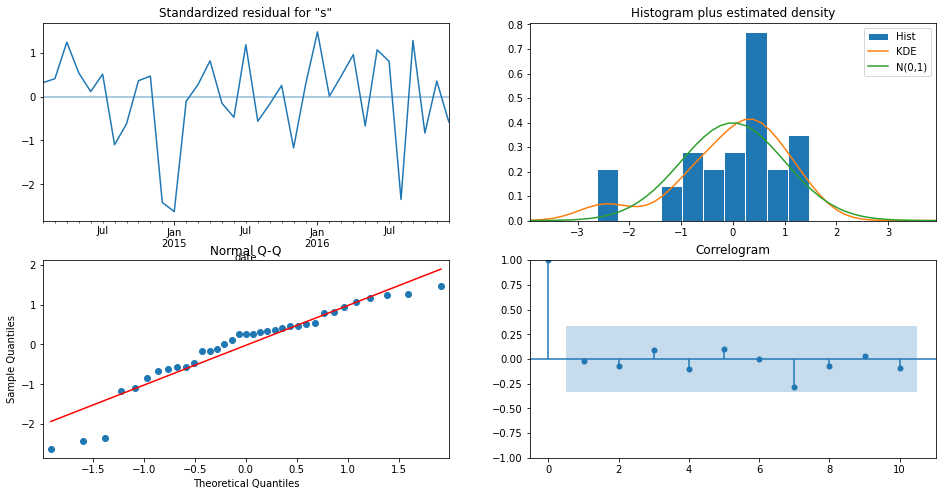

In [128]:
store_1_result.plot_diagnostics(figsize=(16,8))
plt.show()

In [129]:
#Now predict values in the future

start = len(store_1_train)
end = len(store_1_train) + len(store_1_test) - 1

store_1_prediction = store_1_result.predict(start,end).rename('SARIMA model predictions')
store_1_prediction


#predicting 2017.. but we already have 2017 value

2017-01-31    1938.838710
2017-02-28    2100.319244
2017-03-31    2487.419355
2017-04-30    2897.437634
2017-05-31    3066.032258
2017-06-30    3253.237634
2017-07-31    3502.322581
2017-08-31    3037.774194
2017-09-30    2893.670968
2017-10-31    2709.064516
2017-11-30    2864.804301
2017-12-31    2122.290323
Freq: M, Name: SARIMA model predictions, dtype: float64

Text(0.5, 1.0, 'store 1 sales')

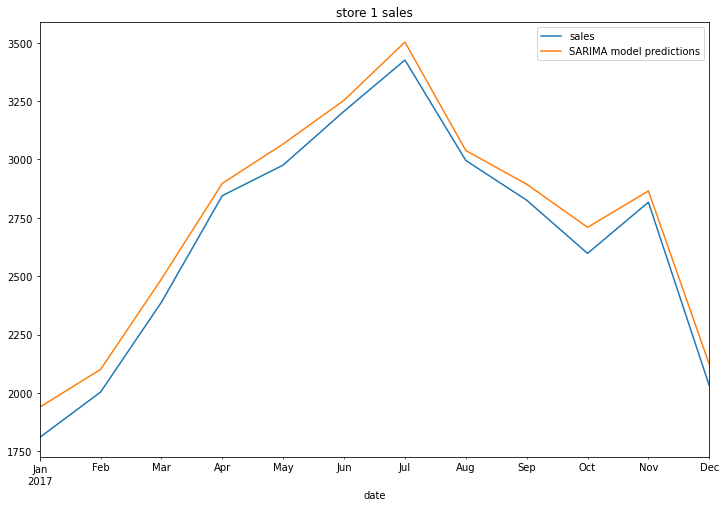

In [130]:
store_1_test.plot(figsize=(12,8),legend=True)
store_1_prediction.plot(legend=True)
plt.title("store 1 sales")

In [131]:
#Evaluation our model

from sklearn.metrics import mean_squared_error,mean_absolute_error
from statsmodels.tools.eval_measures import rmse



In [132]:
mean_squared_error(store_1_test,store_1_prediction)

7057.017024476113

In [133]:
rmse(store_1_test,store_1_prediction)

84.00605349899561

In [134]:
store_1_test.mean()

2659.885304659498

In [135]:
#Comparing the mean value to the root mean square value we can say that the model had predicted in a good way

C:\Users\Shahma\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Text(0.5, 1.0, 'store 1 sales')

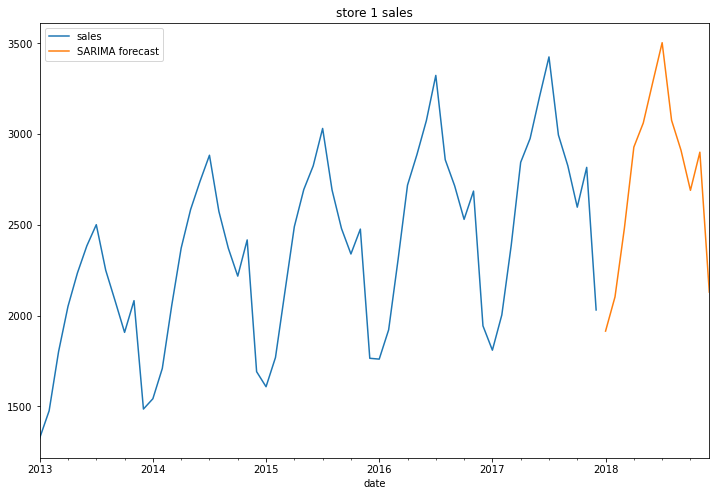

In [136]:
#Now let us forecast into the unknown future

store_1_model_final = SARIMAX(store_1,order=(0, 1, 1),seasonal_order=(2, 0, 0, 12),enforce_invertibility=False)
store_1_result_final = store_1_model_final.fit()
store_1_forecast = store_1_result_final.predict(len(store_1),len(store_1)+11,typ='levels').rename('SARIMA forecast')
store_1.plot(legend=True,figsize=(12,8))
store_1_forecast.plot(legend=True)
plt.title("store 1 sales")

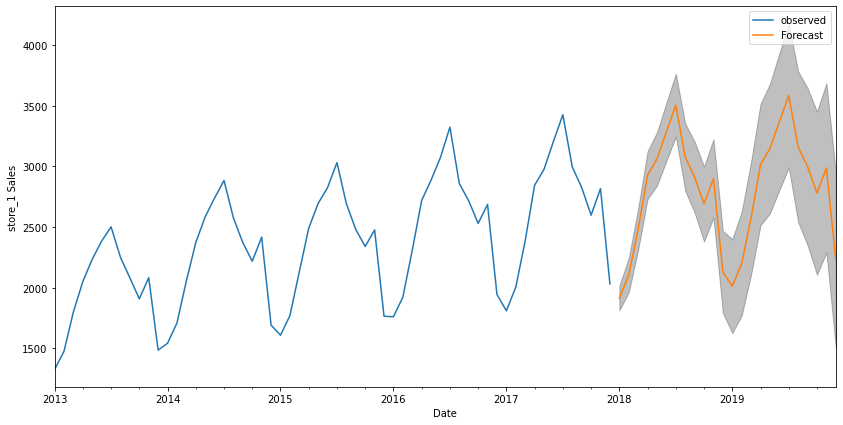

In [137]:
store_1_pred = store_1_result_final.get_forecast(steps=24)
store_1_pred_ci = store_1_pred.conf_int()
ax = store_1.plot(label='observed',figsize=(14,7))
store_1_pred.predicted_mean.plot(ax=ax,label='Forecast')
ax.fill_between(store_1_pred_ci.index,
               store_1_pred_ci.iloc[:,0],
               store_1_pred_ci.iloc[:,1],color='k',alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('store_1 Sales')
plt.legend()
plt.show()